# Import Packages

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, isnan, count

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [3]:
# create Spark session
spark = SparkSession.builder.master("local[*]").appName("exploratory_data_analysis").getOrCreate()

# load dataset
DATA_PATH = "data/ciciot2023_filtered/*-c000.snappy.parquet"
df = spark.read.parquet(DATA_PATH)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/25 14:11:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/25 14:11:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/25 14:11:58 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: data/ciciot2023_filtered/*-c000.snappy.parquet.
java.io.FileNotFoundException: File data/ciciot2023_filtered/*-c000.snappy.parquet does not exist
	at org.apache.hadoop

# Dataset Information
| Feature | Description |
|---------|-------------|
| flow_duration | Duration of the packet's flow |
| Header Length | Header Length |
| Protocol Type | IP, UDP, TCP, IGMP, ICMP, Unknown (Integers) |
| Duration | Time-to-Live (ttl) |
| Rate | Rate of packet transmission in a flow |
| Srate | Rate of outbound packets transmission in a flow |
| Drate | Rate of inbound packets transmission in a flow |
| fin flag number | Fin flag value |
| syn flag number | Syn flag value |
| rst flag number | Rst flag value |
| psh flag number | Psh flag value |
| ack flag number | Ack flag value |
| ece flag number | Ece flag value |
| cwr flag number | Cwr flag value |
| ack count | Number of packets with ack flag set in the same flow |
| syn count | Number of packets with syn flag set in the same flow |
| fin count | Number of packets with fin flag set in the same flow |
| urg count | Number of packets with urg flag set in the same flow |
| rst count | Number of packets with rst flag set in the same flow |
| HTTP | Indicates if the application layer protocol is HTTP |
| HTTPS | Indicates if the application layer protocol is HTTPS |
| DNS | Indicates if the application layer protocol is DNS |
| Telnet | Indicates if the application layer protocol is Telnet |
| SMTP | Indicates if the application layer protocol is SMTP |
| SSH | Indicates if the application layer protocol is SSH |
| IRC | Indicates if the application layer protocol is IRC |
| TCP | Indicates if the transport layer protocol is TCP |
| UDP | Indicates if the transport layer protocol is UDP |
| DHCP | Indicates if the application layer protocol is DHCP |
| ARP | Indicates if the link layer protocol is ARP |
| ICMP | Indicates if the network layer protocol is ICMP |
| IPv | Indicates if the network layer protocol is IP |
| LLC | Indicates if the link layer protocol is LLC |
| Tot sum | Summation of packets lengths in flow |
| Min | Minimum packet length in the flow |
| Max | Maximum packet length in the flow |
| AVG | Average packet length in the flow |
| Std | Standard deviation of packet length in the flow |
| Tot size | Packet's length |
| IAT | The time difference with the previous packet |
| Number | The number of packets in the flow |
| Magnitude | (Average of the lengths of incoming packets in the flow + average of the lengths of outgoing packets in the flow)^0.5 |
| Radius | (Variance of the lengths of incoming packets in the flow + variance of the lengths of outgoing packets in the flow)^0.5 |
| Covariance | Covariance of the lengths of incoming and outgoing packets |
| Variance | Variance of the lengths of incoming packets in the flow / variance of the lengths of outgoing packets in the flow |
| Weight | Number of incoming packets × Number of outgoing packets |


In [4]:
df.printSchema()

root
 |-- flow_duration: double (nullable = true)
 |-- Header_Length: double (nullable = true)
 |-- Protocol Type: double (nullable = true)
 |-- Duration: double (nullable = true)
 |-- Rate: double (nullable = true)
 |-- Srate: double (nullable = true)
 |-- Drate: double (nullable = true)
 |-- fin_flag_number: double (nullable = true)
 |-- syn_flag_number: double (nullable = true)
 |-- rst_flag_number: double (nullable = true)
 |-- psh_flag_number: double (nullable = true)
 |-- ack_flag_number: double (nullable = true)
 |-- ece_flag_number: double (nullable = true)
 |-- cwr_flag_number: double (nullable = true)
 |-- ack_count: double (nullable = true)
 |-- syn_count: double (nullable = true)
 |-- fin_count: double (nullable = true)
 |-- urg_count: double (nullable = true)
 |-- rst_count: double (nullable = true)
 |-- HTTP: double (nullable = true)
 |-- HTTPS: double (nullable = true)
 |-- DNS: double (nullable = true)
 |-- Telnet: double (nullable = true)
 |-- SMTP: double (nullable = 

In [5]:
df.describe().show()

25/11/25 14:12:00 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+------------------+------------------+------------------+-----------------+-----------------+-------+--------------------+--------------------+-------------------+-------------------+------------------+--------------------+--------------------+--------------------+------------------+--------------------+-----------------+------------------+-------------------+------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+-------------------+-------+--------------------+--------------------+-------------------+-------------------+-----------------+------------------+------------------+-----------------+------------------+-----------------+-------------------+------------------+------------------+-----------------+--------------------+-------------------+------------------+-----------------+--------+
|summary|     flow_duration|     Header_Length|     Protocol Type|          Durat

In [6]:
df.show(5)

+------------------+-------------+-------------+--------+-----------------+-----------------+-----+---------------+---------------+---------------+---------------+---------------+---------------+---------------+---------+---------+---------+---------+---------+----+-----+---+------+----+---+---+---+---+----+---+----+---+---+-------+------+------+------------------+------------------+--------+--------------------+------+------------------+------------------+------------------+--------+------+-------------------+--------+
|     flow_duration|Header_Length|Protocol Type|Duration|             Rate|            Srate|Drate|fin_flag_number|syn_flag_number|rst_flag_number|psh_flag_number|ack_flag_number|ece_flag_number|cwr_flag_number|ack_count|syn_count|fin_count|urg_count|rst_count|HTTP|HTTPS|DNS|Telnet|SMTP|SSH|IRC|TCP|UDP|DHCP|ARP|ICMP|IPv|LLC|Tot sum|   Min|   Max|               AVG|               Std|Tot size|                 IAT|Number|          Magnitue|            Radius|        Covar

In [7]:
# shape of the dataframe
num_rows = df.count()
num_cols = len(df.columns)
print(f"Number of rows: {num_rows}, Number of columns: {num_cols}")

Number of rows: 1952328, Number of columns: 48


In [8]:
df = df.toDF(*[c.lower().replace(' ', '_') for c in df.columns])
df.show(5)

+------------------+-------------+-------------+--------+-----------------+-----------------+-----+---------------+---------------+---------------+---------------+---------------+---------------+---------------+---------+---------+---------+---------+---------+----+-----+---+------+----+---+---+---+---+----+---+----+---+---+-------+------+------+------------------+------------------+--------+--------------------+------+------------------+------------------+------------------+--------+------+-------------------+--------+
|     flow_duration|header_length|protocol_type|duration|             rate|            srate|drate|fin_flag_number|syn_flag_number|rst_flag_number|psh_flag_number|ack_flag_number|ece_flag_number|cwr_flag_number|ack_count|syn_count|fin_count|urg_count|rst_count|http|https|dns|telnet|smtp|ssh|irc|tcp|udp|dhcp|arp|icmp|ipv|llc|tot_sum|   min|   max|               avg|               std|tot_size|                 iat|number|          magnitue|            radius|        covar

In [9]:
numeric_cols = [c for c in df.columns if c not in ['label', 'category']]
string_cols = ['label', 'category']

# Check nulls for numeric columns (can use isnan)
null_counts_numeric = df.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in numeric_cols])

# Check nulls for string columns (only use isNull)
null_counts_string = df.select([count(when(col(c).isNull(), c)).alias(c) for c in string_cols])

# Combine the results
null_counts = null_counts_numeric.select(*numeric_cols).crossJoin(null_counts_string.select(*string_cols))
null_counts.show()

+-------------+-------------+-------------+--------+----+-----+-----+---------------+---------------+---------------+---------------+---------------+---------------+---------------+---------+---------+---------+---------+---------+----+-----+---+------+----+---+---+---+---+----+---+----+---+---+-------+---+---+---+---+--------+---+------+--------+------+----------+--------+------+-----+--------+
|flow_duration|header_length|protocol_type|duration|rate|srate|drate|fin_flag_number|syn_flag_number|rst_flag_number|psh_flag_number|ack_flag_number|ece_flag_number|cwr_flag_number|ack_count|syn_count|fin_count|urg_count|rst_count|http|https|dns|telnet|smtp|ssh|irc|tcp|udp|dhcp|arp|icmp|ipv|llc|tot_sum|min|max|avg|std|tot_size|iat|number|magnitue|radius|covariance|variance|weight|label|category|
+-------------+-------------+-------------+--------+----+-----+-----+---------------+---------------+---------------+---------------+---------------+---------------+---------------+---------+---------+-

In [10]:
# check for infinite values in numeric columns
infinite_counts = df.select([count(when(col(c) == float('inf'), c)).alias(c) for c in numeric_cols])
infinite_counts.show()

+-------------+-------------+-------------+--------+----+-----+-----+---------------+---------------+---------------+---------------+---------------+---------------+---------------+---------+---------+---------+---------+---------+----+-----+---+------+----+---+---+---+---+----+---+----+---+---+-------+---+---+---+---+--------+---+------+--------+------+----------+--------+------+
|flow_duration|header_length|protocol_type|duration|rate|srate|drate|fin_flag_number|syn_flag_number|rst_flag_number|psh_flag_number|ack_flag_number|ece_flag_number|cwr_flag_number|ack_count|syn_count|fin_count|urg_count|rst_count|http|https|dns|telnet|smtp|ssh|irc|tcp|udp|dhcp|arp|icmp|ipv|llc|tot_sum|min|max|avg|std|tot_size|iat|number|magnitue|radius|covariance|variance|weight|
+-------------+-------------+-------------+--------+----+-----+-----+---------------+---------------+---------------+---------------+---------------+---------------+---------------+---------+---------+---------+---------+---------+-

In [11]:
df.groupBy('category').count().orderBy('count', ascending=False).show()

+----------+-------+
|  category|  count|
+----------+-------+
|    Benign|1098195|
|  Spoofing| 486504|
|     Recon| 354565|
|BruteForce|  13064|
+----------+-------+



In [12]:
df.groupBy('label').count().orderBy('count', ascending=False).show()

+--------------------+-------+
|               label|  count|
+--------------------+-------+
|       BenignTraffic|1098195|
|    MITM-ArpSpoofing| 307593|
|        DNS_Spoofing| 178911|
| Recon-HostDiscovery| 134378|
|        Recon-OSScan|  98259|
|      Recon-PortScan|  82284|
|   VulnerabilityScan|  37382|
|DictionaryBruteForce|  13064|
|     Recon-PingSweep|   2262|
+--------------------+-------+



**Observation:**
- The dataset is imbalance, especially for specific attacks in a category

In [13]:
df.groupBy('protocol_type').count().orderBy('count', ascending=False).show()

+-------------+------+
|protocol_type| count|
+-------------+------+
|          6.0|785610|
|          7.1|231944|
|          8.2|124795|
|          9.3| 81094|
|         17.0| 67819|
|          5.4| 57559|
|         10.4| 57218|
|         11.5| 42111|
|          6.5| 39822|
|         12.6| 34183|
|         13.7| 29350|
|         15.9| 29310|
|          7.6| 27762|
|         14.8| 26296|
|          8.7| 19918|
|          4.8| 18331|
|          5.9| 16897|
|          5.5| 16630|
|          6.6| 15609|
|          9.8| 14431|
+-------------+------+
only showing top 20 rows


## Understanding Protocol Type Values

The `protocol_type` field contains **floating-point values** because of the **aggregation process** used during feature extraction:

### Why Protocol Type is Float:

1. **Original Values**: The protocol type starts as integer values from the IP header:
   - ICMP = 1
   - IGMP = 2  
   - TCP = 6
   - UDP = 17
   - etc.

2. **Aggregation Process**: The feature extraction code aggregates multiple packets into time windows. During aggregation:
   - It takes the **mode** (most common value) of protocol types in that window
   - It calculates the **mean** of most other numeric features
   - When the mode returns multiple values or pandas operations involve mixed types, the result becomes float

3. **Mixed Traffic**: When a time window contains packets with different protocols, the averaging process creates decimal values like:
   - 6.0 = pure TCP traffic
   - 7.1 = mostly TCP (6) with some other protocol
   - 13.7 = mostly UDP (17) with other protocols
   - 4.9 = mostly IPv4 (4) with mixed traffic

In [14]:
from pyspark.sql.functions import countDistinct
for col_name in df.columns:
    unique_count = df.select(countDistinct(col_name)).collect()[0][0]
    print(f"Column '{col_name}' has {unique_count} unique values.")

Column 'flow_duration' has 1931678 unique values.
Column 'header_length' has 1569074 unique values.
Column 'header_length' has 1569074 unique values.
Column 'protocol_type' has 1113 unique values.
Column 'duration' has 8992 unique values.
Column 'protocol_type' has 1113 unique values.
Column 'duration' has 8992 unique values.
Column 'rate' has 1939584 unique values.
Column 'rate' has 1939584 unique values.
Column 'srate' has 1939584 unique values.
Column 'drate' has 1 unique values.
Column 'srate' has 1939584 unique values.
Column 'drate' has 1 unique values.
Column 'fin_flag_number' has 2 unique values.
Column 'syn_flag_number' has 2 unique values.
Column 'fin_flag_number' has 2 unique values.
Column 'syn_flag_number' has 2 unique values.
Column 'rst_flag_number' has 2 unique values.
Column 'psh_flag_number' has 2 unique values.
Column 'rst_flag_number' has 2 unique values.
Column 'psh_flag_number' has 2 unique values.
Column 'ack_flag_number' has 2 unique values.
Column 'ece_flag_num

In [15]:
binary_cols = [col for col in df.columns if set(df.select(col).distinct().rdd.flatMap(lambda x: x).collect()).issubset({0.0, 1.0})]
binary_cols

['drate',
 'fin_flag_number',
 'syn_flag_number',
 'rst_flag_number',
 'psh_flag_number',
 'ack_flag_number',
 'ece_flag_number',
 'cwr_flag_number',
 'http',
 'https',
 'dns',
 'telnet',
 'smtp',
 'ssh',
 'irc',
 'tcp',
 'udp',
 'dhcp',
 'arp',
 'icmp',
 'ipv',
 'llc']

In [16]:
for col_name in binary_cols:
    df.groupBy(col_name).count().orderBy(col_name).show()

+-----+-------+
|drate|  count|
+-----+-------+
|  0.0|1952328|
+-----+-------+

+---------------+-------+
|fin_flag_number|  count|
+---------------+-------+
|            0.0|1951921|
|            1.0|    407|
+---------------+-------+

+---------------+-------+
|syn_flag_number|  count|
+---------------+-------+
|            0.0|1896527|
|            1.0|  55801|
+---------------+-------+

+---------------+-------+
|rst_flag_number|  count|
+---------------+-------+
|            0.0|1915426|
|            1.0|  36902|
+---------------+-------+

+---------------+-------+
|psh_flag_number|  count|
+---------------+-------+
|            0.0|1884243|
|            1.0|  68085|
+---------------+-------+

+---------------+-------+
|syn_flag_number|  count|
+---------------+-------+
|            0.0|1896527|
|            1.0|  55801|
+---------------+-------+

+---------------+-------+
|rst_flag_number|  count|
+---------------+-------+
|            0.0|1915426|
|            1.0|  36902|
+---

In [17]:
df.filter(col('telnet') == 1.0).show()

+------------------+-------------+-------------+--------+-----------------+-----------------+-----+---------------+---------------+---------------+---------------+---------------+---------------+---------------+---------+---------+---------+---------+---------+----+-----+---+------+----+---+---+---+---+----+---+----+---+---+-------+----+----+-----------------+------------------+--------+-------------------+------+------------------+----------------+------------------+--------+------+-------------------+--------+
|     flow_duration|header_length|protocol_type|duration|             rate|            srate|drate|fin_flag_number|syn_flag_number|rst_flag_number|psh_flag_number|ack_flag_number|ece_flag_number|cwr_flag_number|ack_count|syn_count|fin_count|urg_count|rst_count|http|https|dns|telnet|smtp|ssh|irc|tcp|udp|dhcp|arp|icmp|ipv|llc|tot_sum| min| max|              avg|               std|tot_size|                iat|number|          magnitue|          radius|        covariance|variance|w

In [18]:
df.filter(col('smtp') == 1.0).show()

+------------------+-------------+-------------+--------+------------------+------------------+-----+---------------+---------------+---------------+---------------+---------------+---------------+---------------+---------+---------+---------+---------+---------+----+-----+---+------+----+---+---+---+---+----+---+----+---+---+-------+----+----+-----------------+------------------+--------+--------------------+------+------------------+------------------+------------------+--------+------+-------------------+--------+
|     flow_duration|header_length|protocol_type|duration|              rate|             srate|drate|fin_flag_number|syn_flag_number|rst_flag_number|psh_flag_number|ack_flag_number|ece_flag_number|cwr_flag_number|ack_count|syn_count|fin_count|urg_count|rst_count|http|https|dns|telnet|smtp|ssh|irc|tcp|udp|dhcp|arp|icmp|ipv|llc|tot_sum| min| max|              avg|               std|tot_size|                 iat|number|          magnitue|            radius|        covariance|

In [19]:
df.filter(col('irc') == 1.0).show()

+------------------+-------------+-------------+--------+------------------+------------------+-----+---------------+---------------+---------------+---------------+---------------+---------------+---------------+---------+---------+---------+---------+---------+----+-----+---+------+----+---+---+---+---+----+---+----+---+---+-------+----+----+------------------+------------------+--------+--------------------+------+------------------+------------------+------------------+--------+------+-------------------+--------+
|     flow_duration|header_length|protocol_type|duration|              rate|             srate|drate|fin_flag_number|syn_flag_number|rst_flag_number|psh_flag_number|ack_flag_number|ece_flag_number|cwr_flag_number|ack_count|syn_count|fin_count|urg_count|rst_count|http|https|dns|telnet|smtp|ssh|irc|tcp|udp|dhcp|arp|icmp|ipv|llc|tot_sum| min| max|               avg|               std|tot_size|                 iat|number|          magnitue|            radius|        covarianc

**Observation:**
- Drate and DHCP features have no variance, should be dropped.
- telnet, smtp and irc provide very little information too, packets with those <br>protocols are all labelled as host discovery attacks, which will make the model flag every packet with them as such

In [20]:
# check the labels for flags
for flag in ['fin_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'syn_flag_number', 'ece_flag_number', 'cwr_flag_number']:
    print(f"Flag: {flag}")
    df.filter(col(flag) == 1.0).groupBy('category').count().orderBy('count', ascending=False).show()

Flag: fin_flag_number
+----------+-----+
|  category|count|
+----------+-----+
|     Recon|  316|
|  Spoofing|   64|
|BruteForce|   22|
|    Benign|    5|
+----------+-----+

Flag: rst_flag_number
+----------+-----+
|  category|count|
+----------+-----+
|     Recon|  316|
|  Spoofing|   64|
|BruteForce|   22|
|    Benign|    5|
+----------+-----+

Flag: rst_flag_number
+----------+-----+
|  category|count|
+----------+-----+
|     Recon|36631|
|  Spoofing|  215|
|    Benign|   55|
|BruteForce|    1|
+----------+-----+

Flag: psh_flag_number
+----------+-----+
|  category|count|
+----------+-----+
|  Spoofing|40837|
|    Benign|19587|
|     Recon| 6616|
|BruteForce| 1045|
+----------+-----+

Flag: ack_flag_number
+----------+-----+
|  category|count|
+----------+-----+
|     Recon|36631|
|  Spoofing|  215|
|    Benign|   55|
|BruteForce|    1|
+----------+-----+

Flag: psh_flag_number
+----------+-----+
|  category|count|
+----------+-----+
|  Spoofing|40837|
|    Benign|19587|
|     Re

**Observation:**
- SYN and RST flags are mostly associated with Recon attacks, as the <br> attacker tries to establish a connection with other devices.

# visualizations

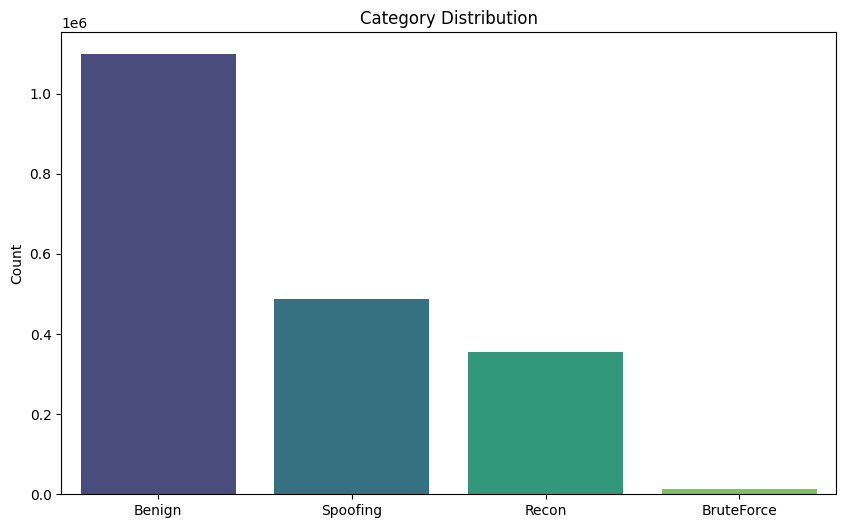

In [21]:
# category distribution plot
category_counts = df.groupBy('category').count().orderBy('count', ascending=False).collect()
categories = [row['category'] for row in category_counts]
counts = [row['count'] for row in category_counts]

plt.figure(figsize=(10, 6))
sns.barplot(x=categories, y=counts, palette='viridis')
plt.title('Category Distribution')
plt.ylabel('Count')
plt.show()

**Observation:**
- could apply undersampling for Benign to match Spoofing and<br>SMOTE for Recon and BruteForce.

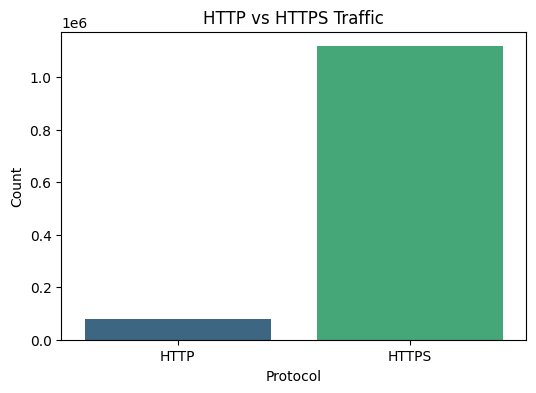

In [22]:
# http vs https plot
http_count = df.filter(col('http') == 1.0).count()
https_count = df.filter(col('https') == 1.0).count()

protocols = ['HTTP', 'HTTPS']
counts = [http_count, https_count]

plt.figure(figsize=(6, 4))
sns.barplot(x=protocols, y=counts, palette='viridis')
plt.title('HTTP vs HTTPS Traffic')
plt.xlabel('Protocol')
plt.ylabel('Count')
plt.show()

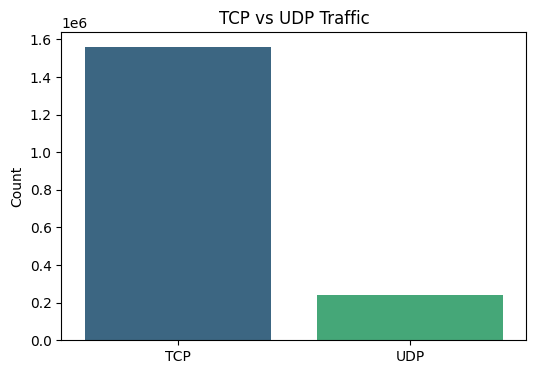

In [23]:
# tcp vs udp vs plot
tcp_count = df.filter(col('tcp') == 1.0).count()
udp_count = df.filter(col('udp') == 1.0).count()

protocols = ['TCP', 'UDP']
counts = [tcp_count, udp_count]

plt.figure(figsize=(6, 4))
sns.barplot(x=protocols, y=counts, palette='viridis')
plt.title('TCP vs UDP Traffic')
plt.ylabel('Count')
plt.show()

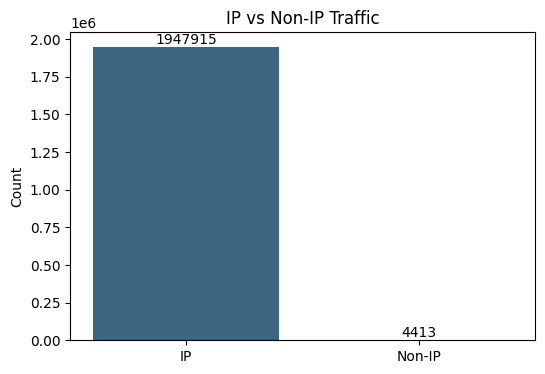

In [24]:
# traffic is IP or non-IP plot
ip_count = df.filter(col('ipv') == 1.0).count()
non_ip_count = df.filter(col('ipv') == 0.0).count()

protocols = ['IP', 'Non-IP']
counts = [ip_count, non_ip_count]

plt.figure(figsize=(6, 4))
sns.barplot(x=protocols, y=counts, palette='viridis')
for i, count in enumerate(counts):
    plt.text(i, count + max(counts)*0.01, str(count), ha='center')
plt.title('IP vs Non-IP Traffic')
plt.ylabel('Count')
plt.show()

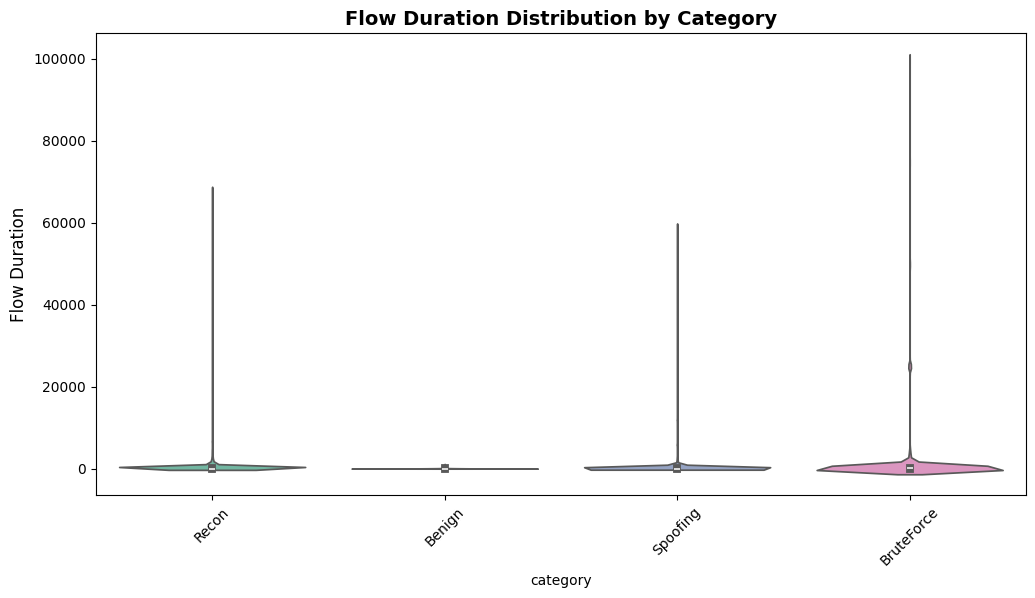

In [25]:
# flow duration distribution by category
flow_duration_data = df.select('category', 'flow_duration').toPandas()

plt.figure(figsize=(12, 6))
sns.violinplot(data=flow_duration_data, x='category', y='flow_duration', palette='Set2')
plt.title('Flow Duration Distribution by Category', fontsize=14, fontweight='bold')
plt.ylabel('Flow Duration', fontsize=12)
plt.xticks(rotation=45)
plt.show()

**Observation:**
- Attack flows all have outliers with long durations.

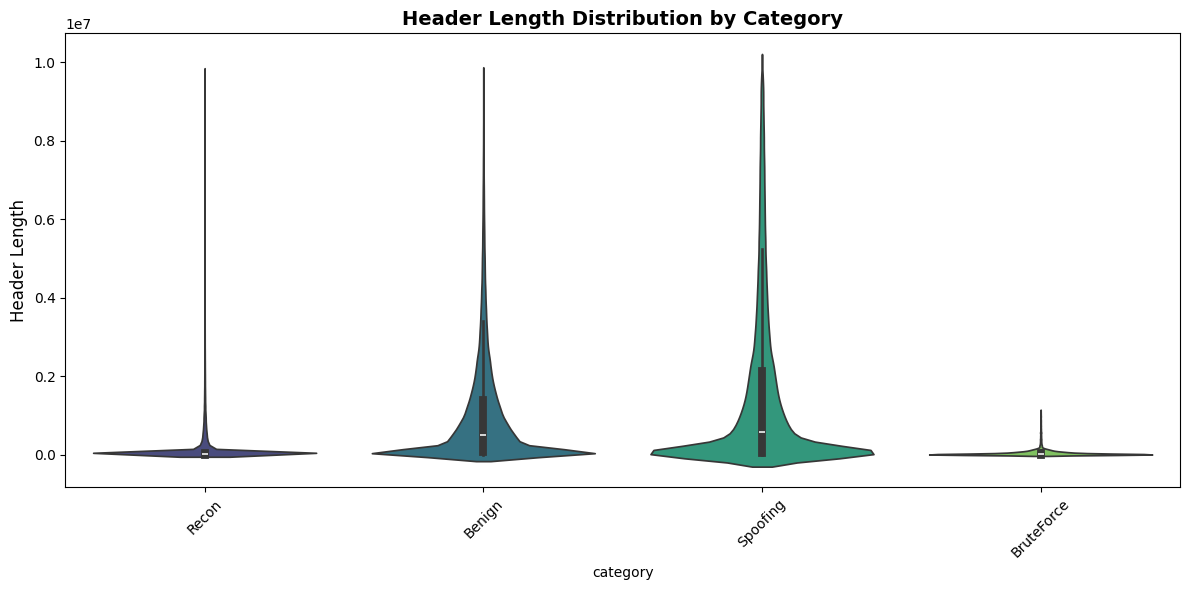

In [26]:
# Violin plot for header_length by category
header_length_data = df.select('header_length', 'category').toPandas()

plt.figure(figsize=(12, 6))
sns.violinplot(data=header_length_data, x='category', y='header_length', palette='viridis')
plt.title('Header Length Distribution by Category', fontsize=14, fontweight='bold')
plt.ylabel('Header Length', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

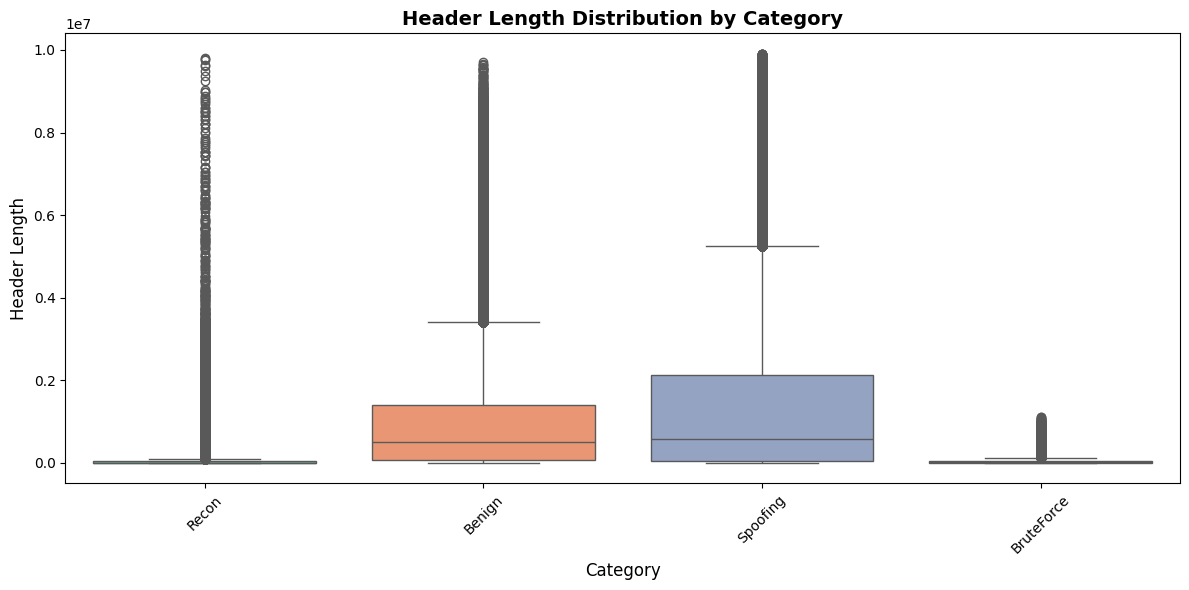

In [27]:
# Box plot alternative
plt.figure(figsize=(12, 6))
sns.boxplot(data=header_length_data, x='category', y='header_length', palette='Set2')
plt.title('Header Length Distribution by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Header Length', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

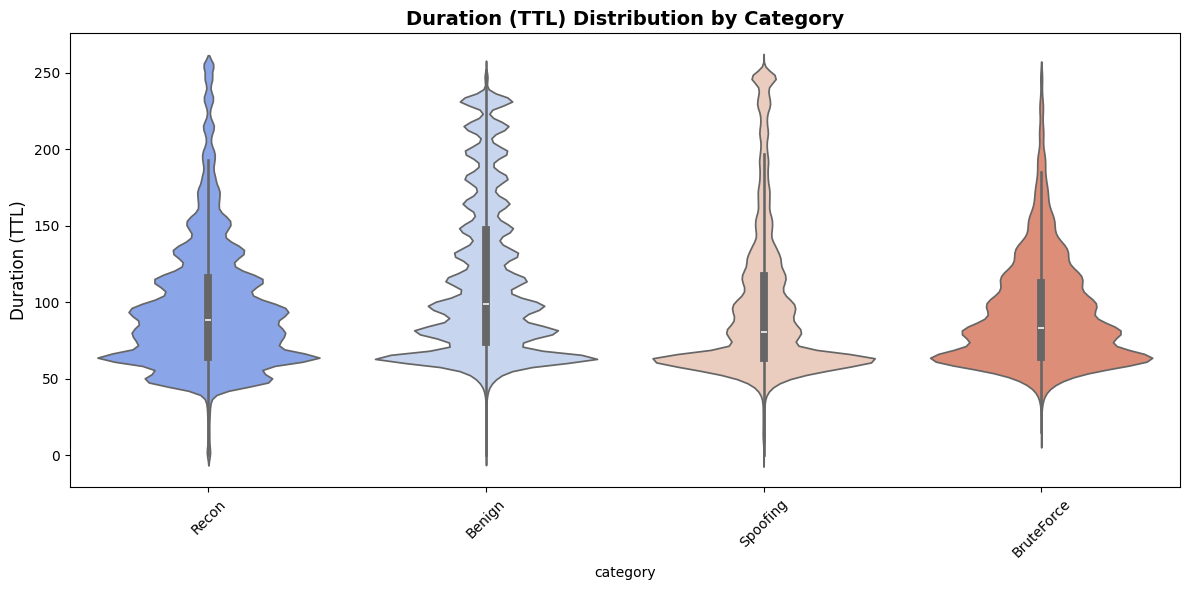

In [28]:
# duration (ttl) distribution by category
ttl_data = df.select('category', 'duration').toPandas()

plt.figure(figsize=(12, 6))
sns.violinplot(data=ttl_data, x='category', y='duration', palette='coolwarm')
plt.title('Duration (TTL) Distribution by Category', fontsize=14, fontweight='bold')
plt.ylabel('Duration (TTL)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

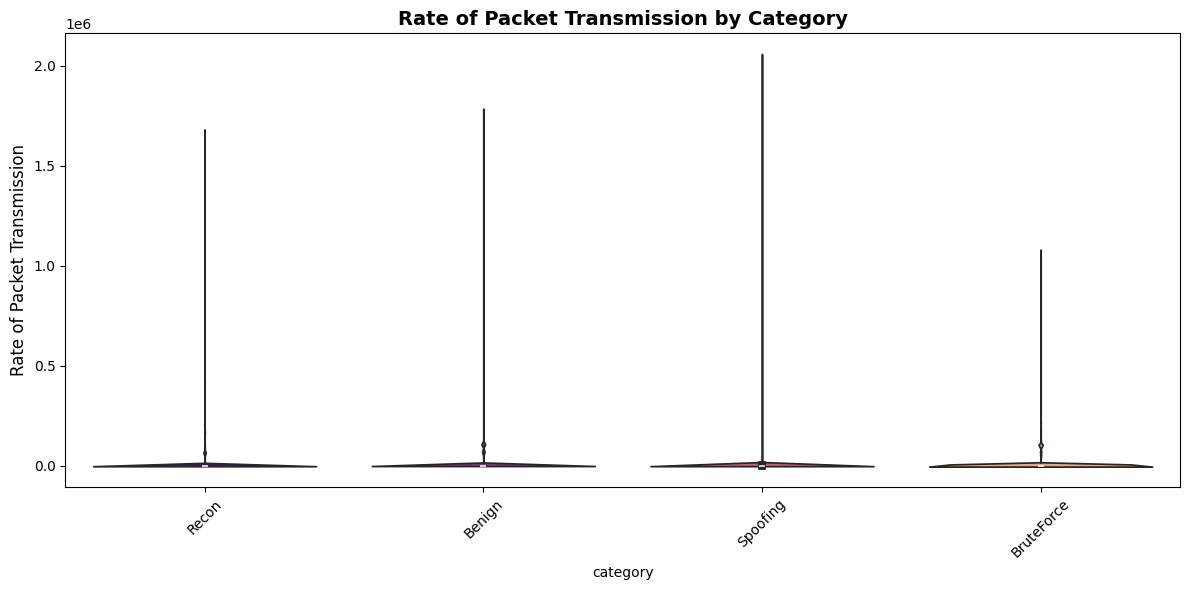

In [29]:
# Rate of packet transmission (Rate) by category plot
rate_data = df.select('category', 'rate').toPandas()

plt.figure(figsize=(12, 6))
sns.violinplot(data=rate_data, x='category', y='rate', palette='magma')
plt.title('Rate of Packet Transmission by Category', fontsize=14, fontweight='bold')
plt.ylabel('Rate of Packet Transmission', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

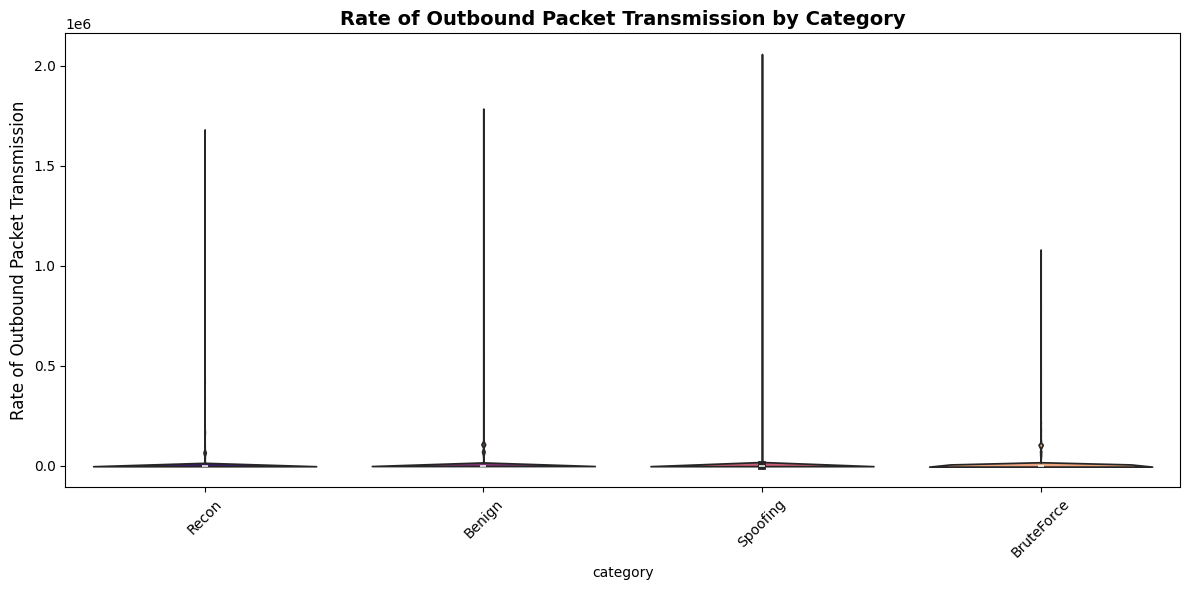

In [30]:
# Rate of outbound packet transmission (srate) by category plot
srate_data = df.select('category', 'srate').toPandas()

plt.figure(figsize=(12, 6))
sns.violinplot(data=srate_data, x='category', y='srate', palette='magma')
plt.title('Rate of Outbound Packet Transmission by Category', fontsize=14, fontweight='bold')
plt.ylabel('Rate of Outbound Packet Transmission', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:**
- The distribution looks identical to rate's

In [31]:
# check if rate and srate are identical
df.select('rate', 'srate').distinct().count() == df.select('rate').distinct().count()

True

**Observation:**
- "srate" and "rate" have the same values across all records --> drop "srate".

# Correlation Analysis

Correlation analysis helps identify:
1. **Multicollinearity**: Features that are highly correlated with each other (redundant information)
2. **Feature Relationships**: How features relate to each other
3. **Feature Selection**: Which features might be redundant and can be dropped

We'll use **Pearson correlation coefficient** which measures linear relationships between features:
- **+1**: Perfect positive correlation
- **0**: No correlation
- **-1**: Perfect negative correlation

In [33]:
sampled_df = df.sample(withReplacement=False, fraction=0.1, seed=42)

pandas_df = sampled_df.select(numeric_cols).toPandas()
print(f"\nDataFrame shape: {pandas_df.shape}")


DataFrame shape: (195479, 46)


In [39]:
# Calculate correlation matrix
correlation_matrix = pandas_df.corr()

print(f"Correlation matrix shape: {correlation_matrix.shape}")
print("\nTop 10 highest correlations:")

# Extract upper triangle to avoid duplicates
import numpy as np
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool) # k=1 starts above main diagonal
)

# Find top correlations
correlations_flat = upper_triangle.unstack().dropna()
top_correlations = correlations_flat.abs().sort_values(ascending=False).head(10)

for (feat1, feat2), corr_val in top_correlations.items():
    actual_corr = correlation_matrix.loc[feat1, feat2]
    print(f"{feat1:20s} <-> {feat2:20s}: {actual_corr:7.4f}")

Correlation matrix shape: (46, 46)

Top 10 highest correlations:
llc                  <-> ipv                 :  1.0000
srate                <-> rate                :  1.0000
radius               <-> std                 :  0.9999
weight               <-> number              :  0.9999
weight               <-> iat                 :  0.9987
number               <-> iat                 :  0.9984
magnitue             <-> avg                 :  0.9729
std                  <-> max                 :  0.9628
radius               <-> max                 :  0.9628
rst_count            <-> header_length       :  0.9383


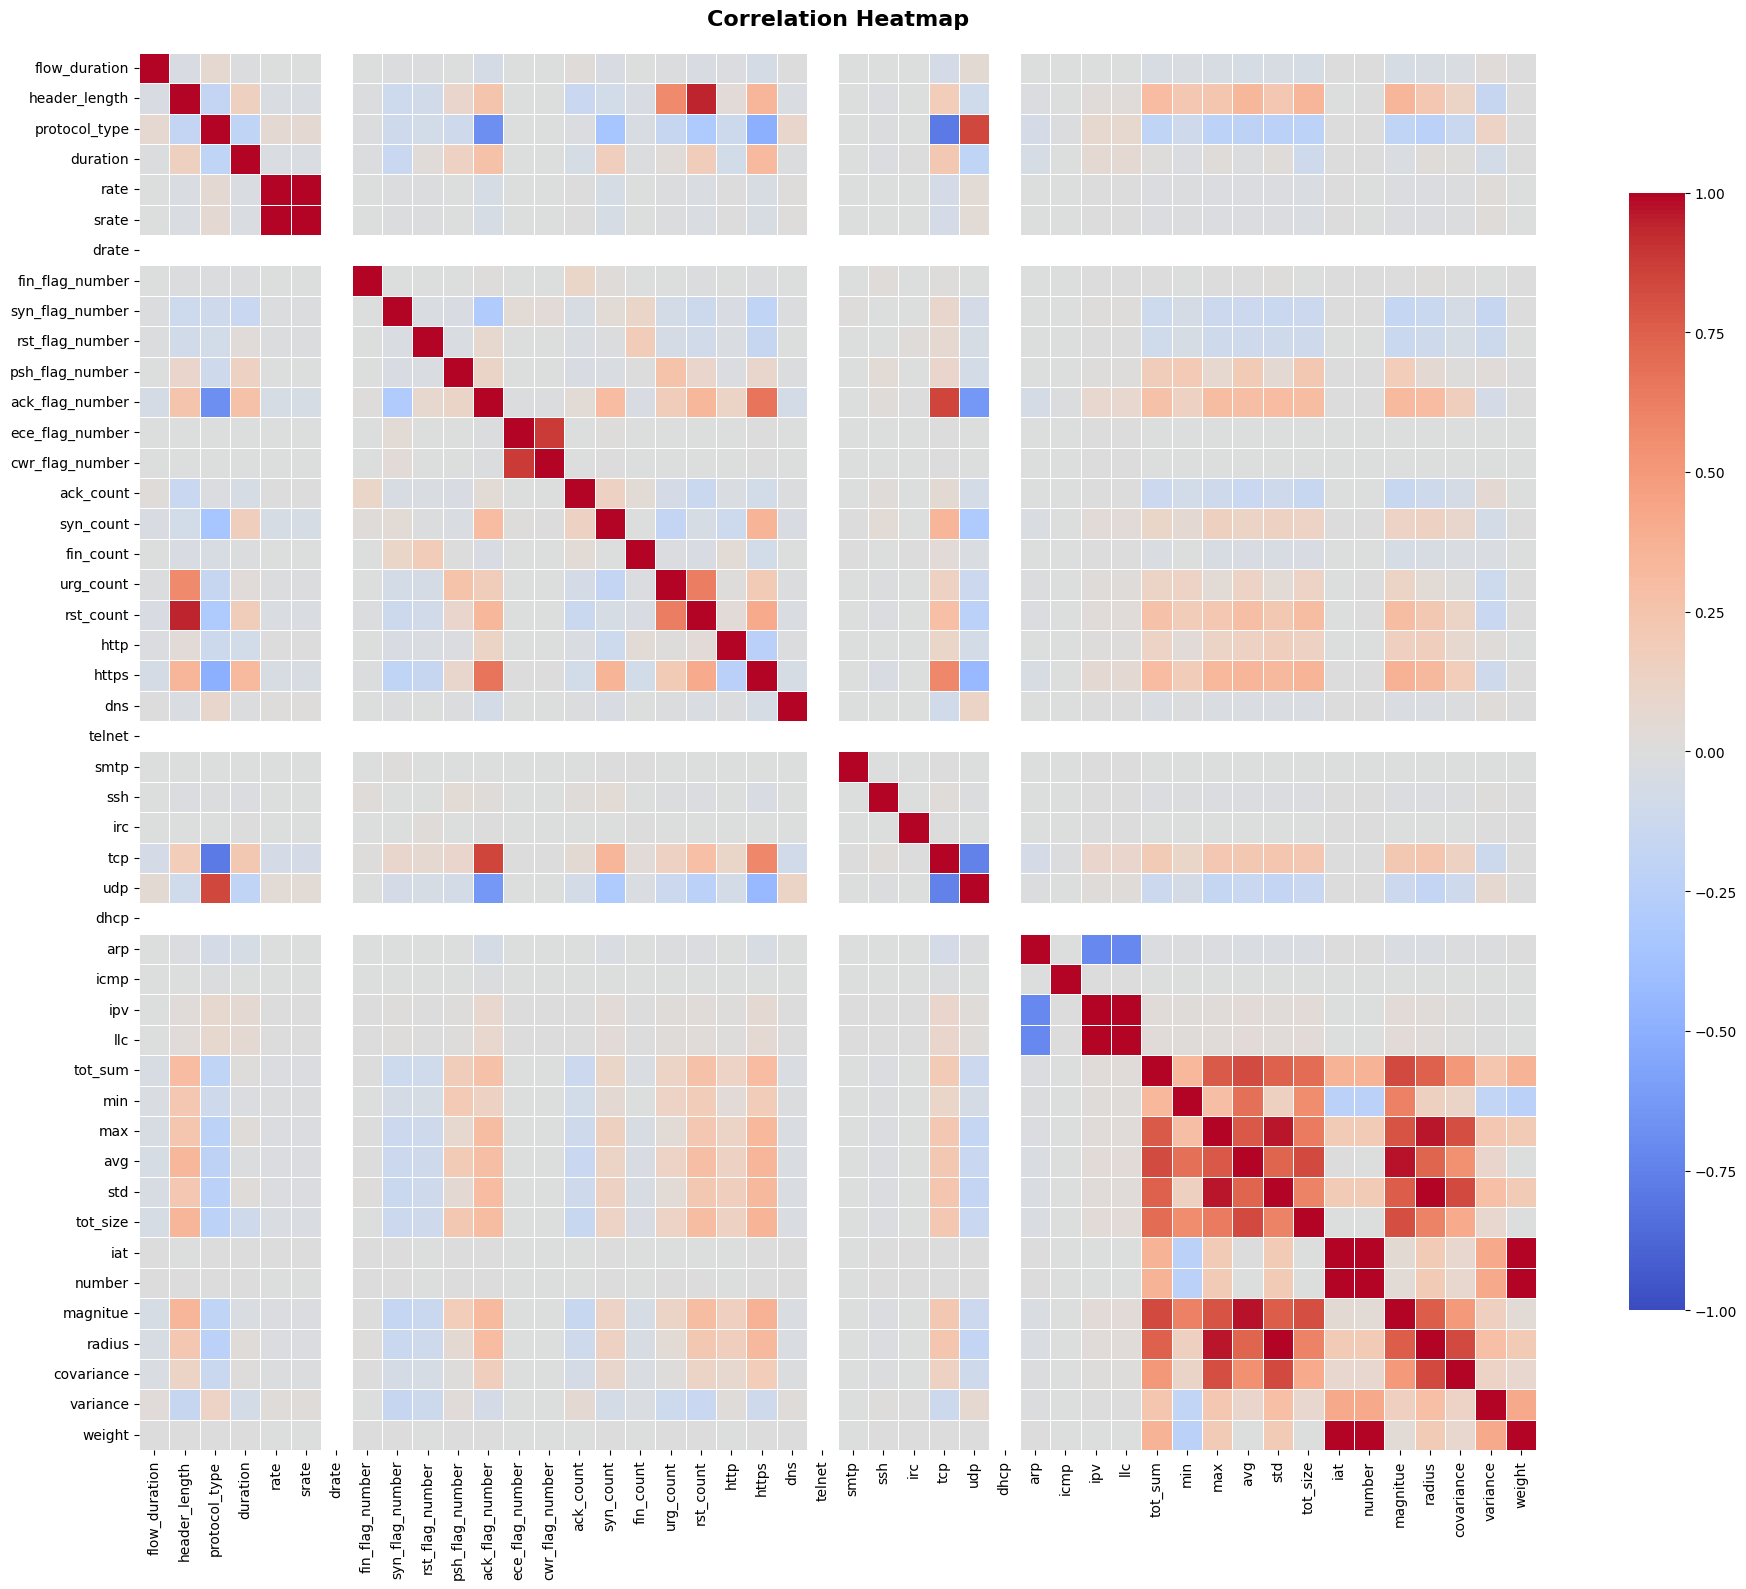

In [35]:
# correlation heatmap plot
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# Identify highly correlated features (multicollinearity check)
# Threshold: |correlation| > 0.9
threshold = 0.9

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    print(f"Found {len(high_corr_pairs)} feature pairs with |correlation| > {threshold}:\n")
    for pair in high_corr_pairs:
        print(f"{pair['Feature 1']:20s} <-> {pair['Feature 2']:20s}: {pair['Correlation']:7.4f}")
else:
    print(f"No feature pairs found with |correlation| > {threshold}")

Found 10 feature pairs with |correlation| > 0.9:

header_length        <-> rst_count           :  0.9383
rate                 <-> srate               :  1.0000
ipv                  <-> llc                 :  1.0000
max                  <-> std                 :  0.9628
max                  <-> radius              :  0.9628
avg                  <-> magnitue            :  0.9729
std                  <-> radius              :  0.9999
iat                  <-> number              :  0.9984
iat                  <-> weight              :  0.9987
number               <-> weight              :  0.9999


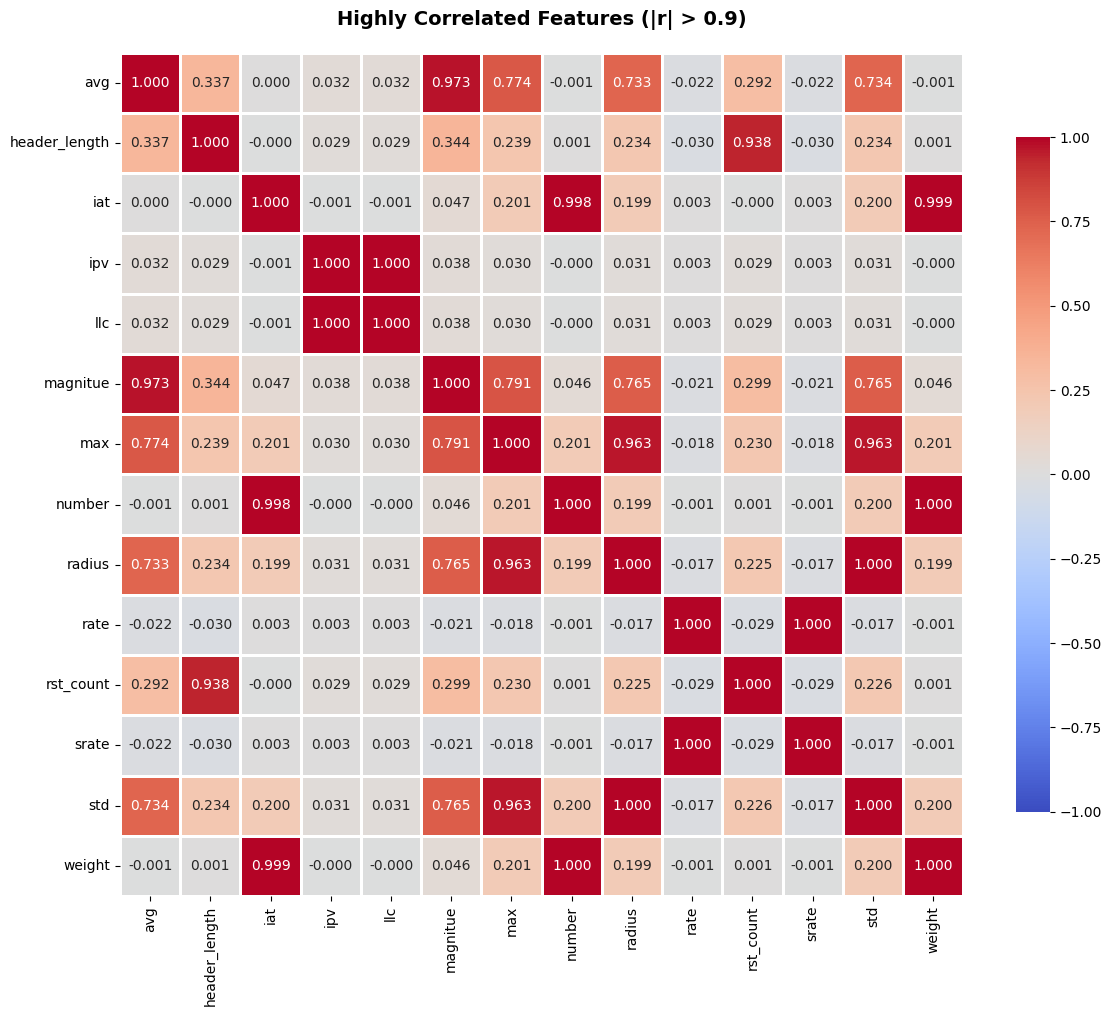

In [ ]:
# Focused heatmap plot
if high_corr_pairs:
    # Extract unique features from high correlation pairs
    high_corr_features = set()
    for pair in high_corr_pairs:
        high_corr_features.add(pair['Feature 1'])
        high_corr_features.add(pair['Feature 2'])
    
    high_corr_features = sorted(list(high_corr_features))
    
    # Create focused correlation matrix
    focused_corr = correlation_matrix.loc[high_corr_features, high_corr_features]
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(focused_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                vmin=-1, vmax=1, square=True, linewidths=1, 
                cbar_kws={"shrink": 0.8})
    plt.title(f'Highly Correlated Features (|r| > {threshold})', 
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
else:
    print("No highly correlated feature pairs to visualize.")

**Observation:**
- (llc, ipv), (number, weight), (radius, std), (rate, srate) are perfectly correlated --> drop at least one feature of each pair.
- radius, weight, std, iat, max, number are highly correlated with more than one feature --> drop them.

# Per-Category Feature Analysis

To improve classification accuracy for specific categories, we need to understand:
1. **Which features best separate each category from others?**
2. **What are the characteristic feature ranges for each category?**
3. **Which features have the most discriminative power?**

In [59]:
key_features = [
    'flow_duration',
    'header_length',
    'duration',
    'rate',
    'ack_count',
    'syn_count',
    'fin_count',
    'urg_count',
    'rst_count',
    'tot_sum',
    'avg',
    'iat',
    'number'
]

sample_for_analysis = df.sample(withReplacement=False, fraction=0.20, seed=42)
analysis_df = sample_for_analysis.select(['category'] + key_features).toPandas()

print(f"Sampled {len(analysis_df)} rows for analysis")
print(f"\nCategory distribution in sample:")
print(analysis_df['category'].value_counts())

Sampled 391209 rows for analysis

Category distribution in sample:
category
Benign        219969
Spoofing       97625
Recon          70957
BruteForce      2658
Name: count, dtype: int64


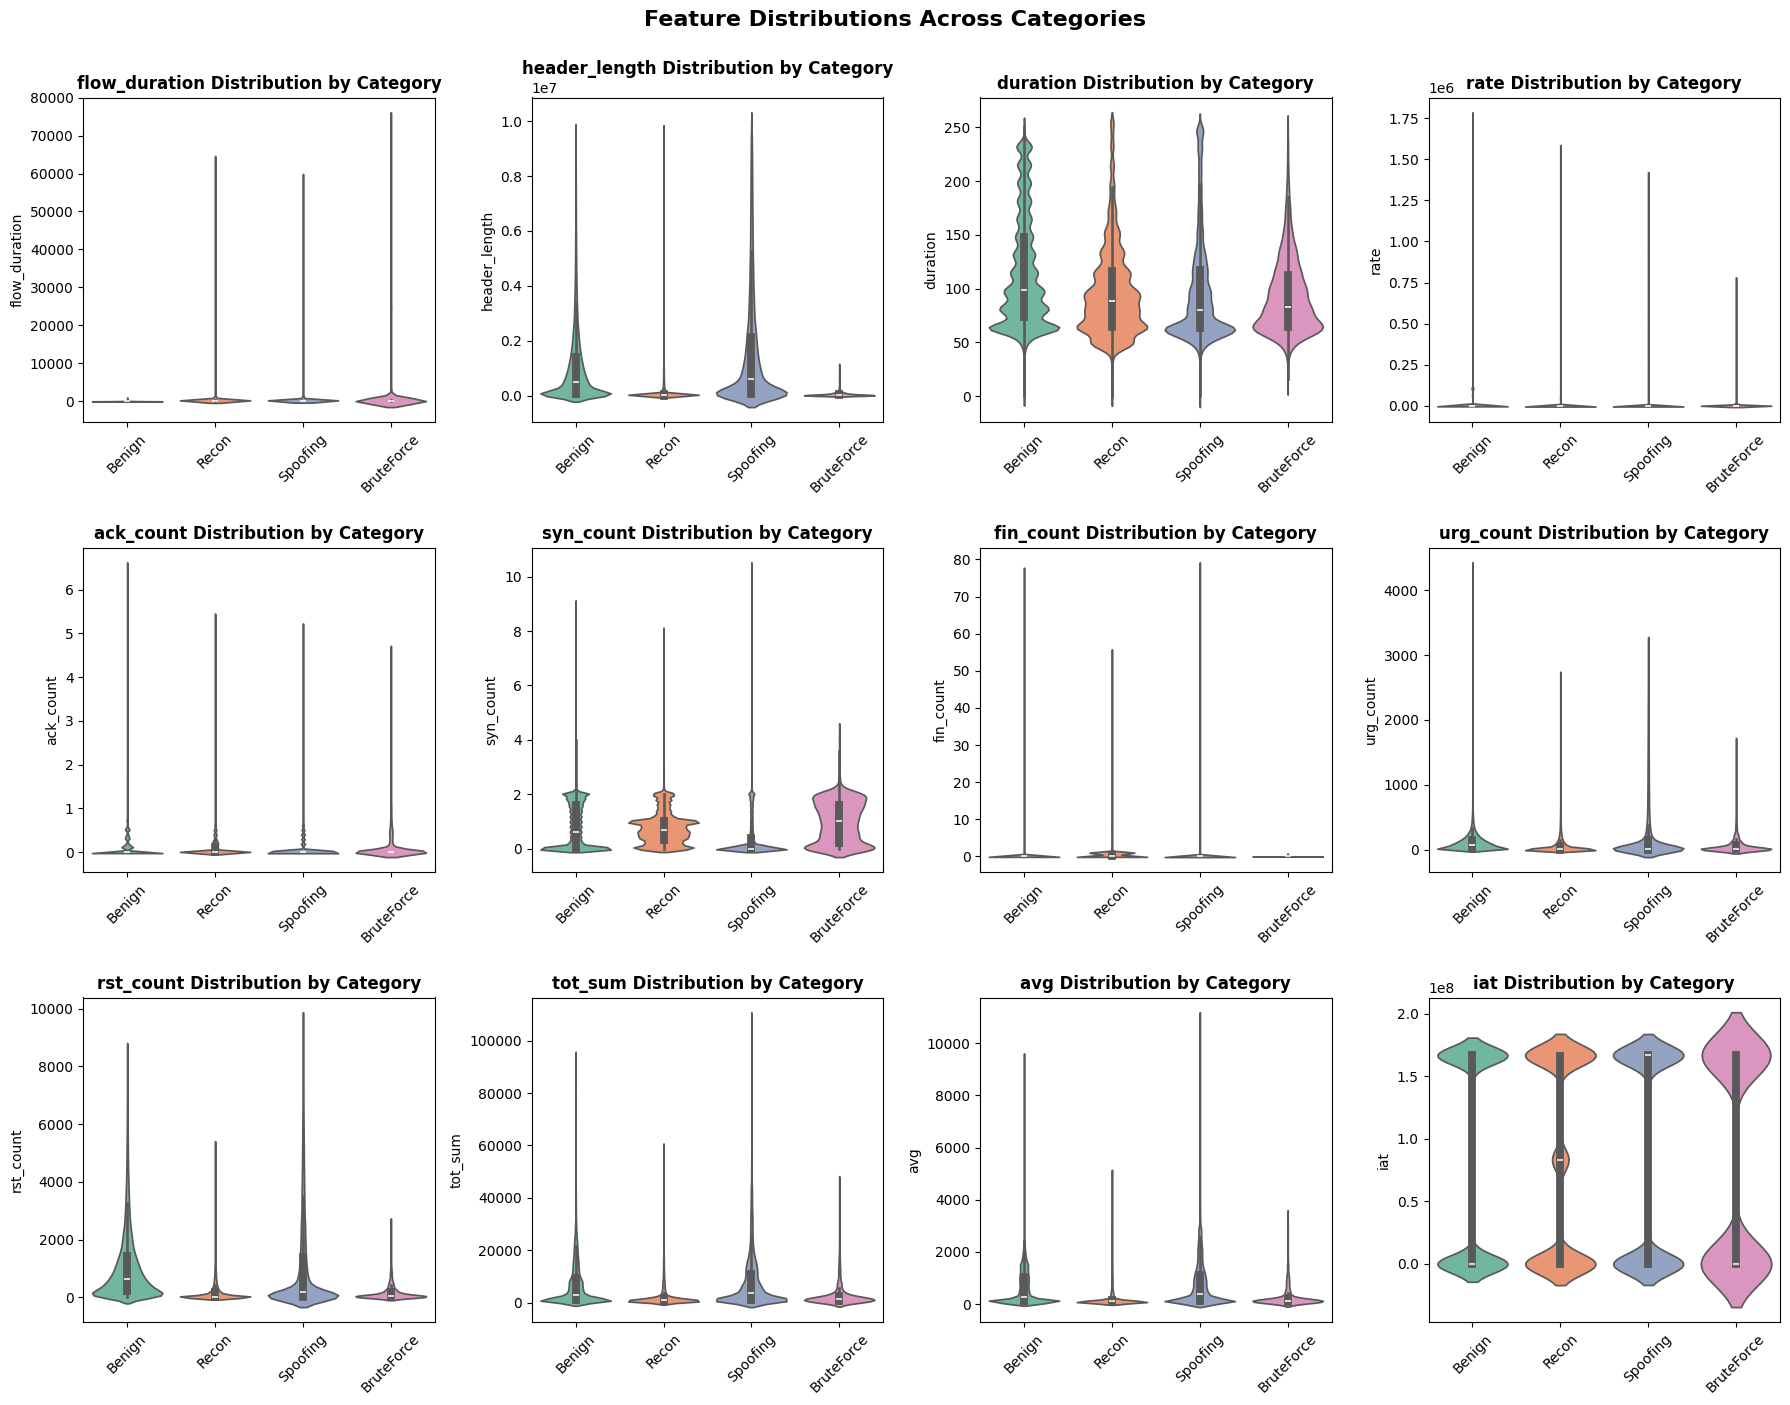

In [60]:
# Compare distributions across categories using violin plots
fig, axes = plt.subplots(3, 4, figsize=(18, 14))
axes = axes.flatten()

for idx, feature in enumerate(key_features[:12]):
    sns.violinplot(data=analysis_df, x='category', y=feature, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{feature} Distribution by Category', fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].tick_params(axis='x', rotation=45)
    
plt.suptitle('Feature Distributions Across Categories', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [85]:
# max urg_count for each category
max_urg_counts = analysis_df.groupby('category')['urg_count'].max().sort_values(ascending=False)
print("Max URG Count by Category:")
for category, max_count in max_urg_counts.items():
    print(f"{category:15s}: {max_count}")

Max URG Count by Category:
Benign         : 4401.7
Spoofing       : 3168.0
Recon          : 2710.73
BruteForce     : 1667.9


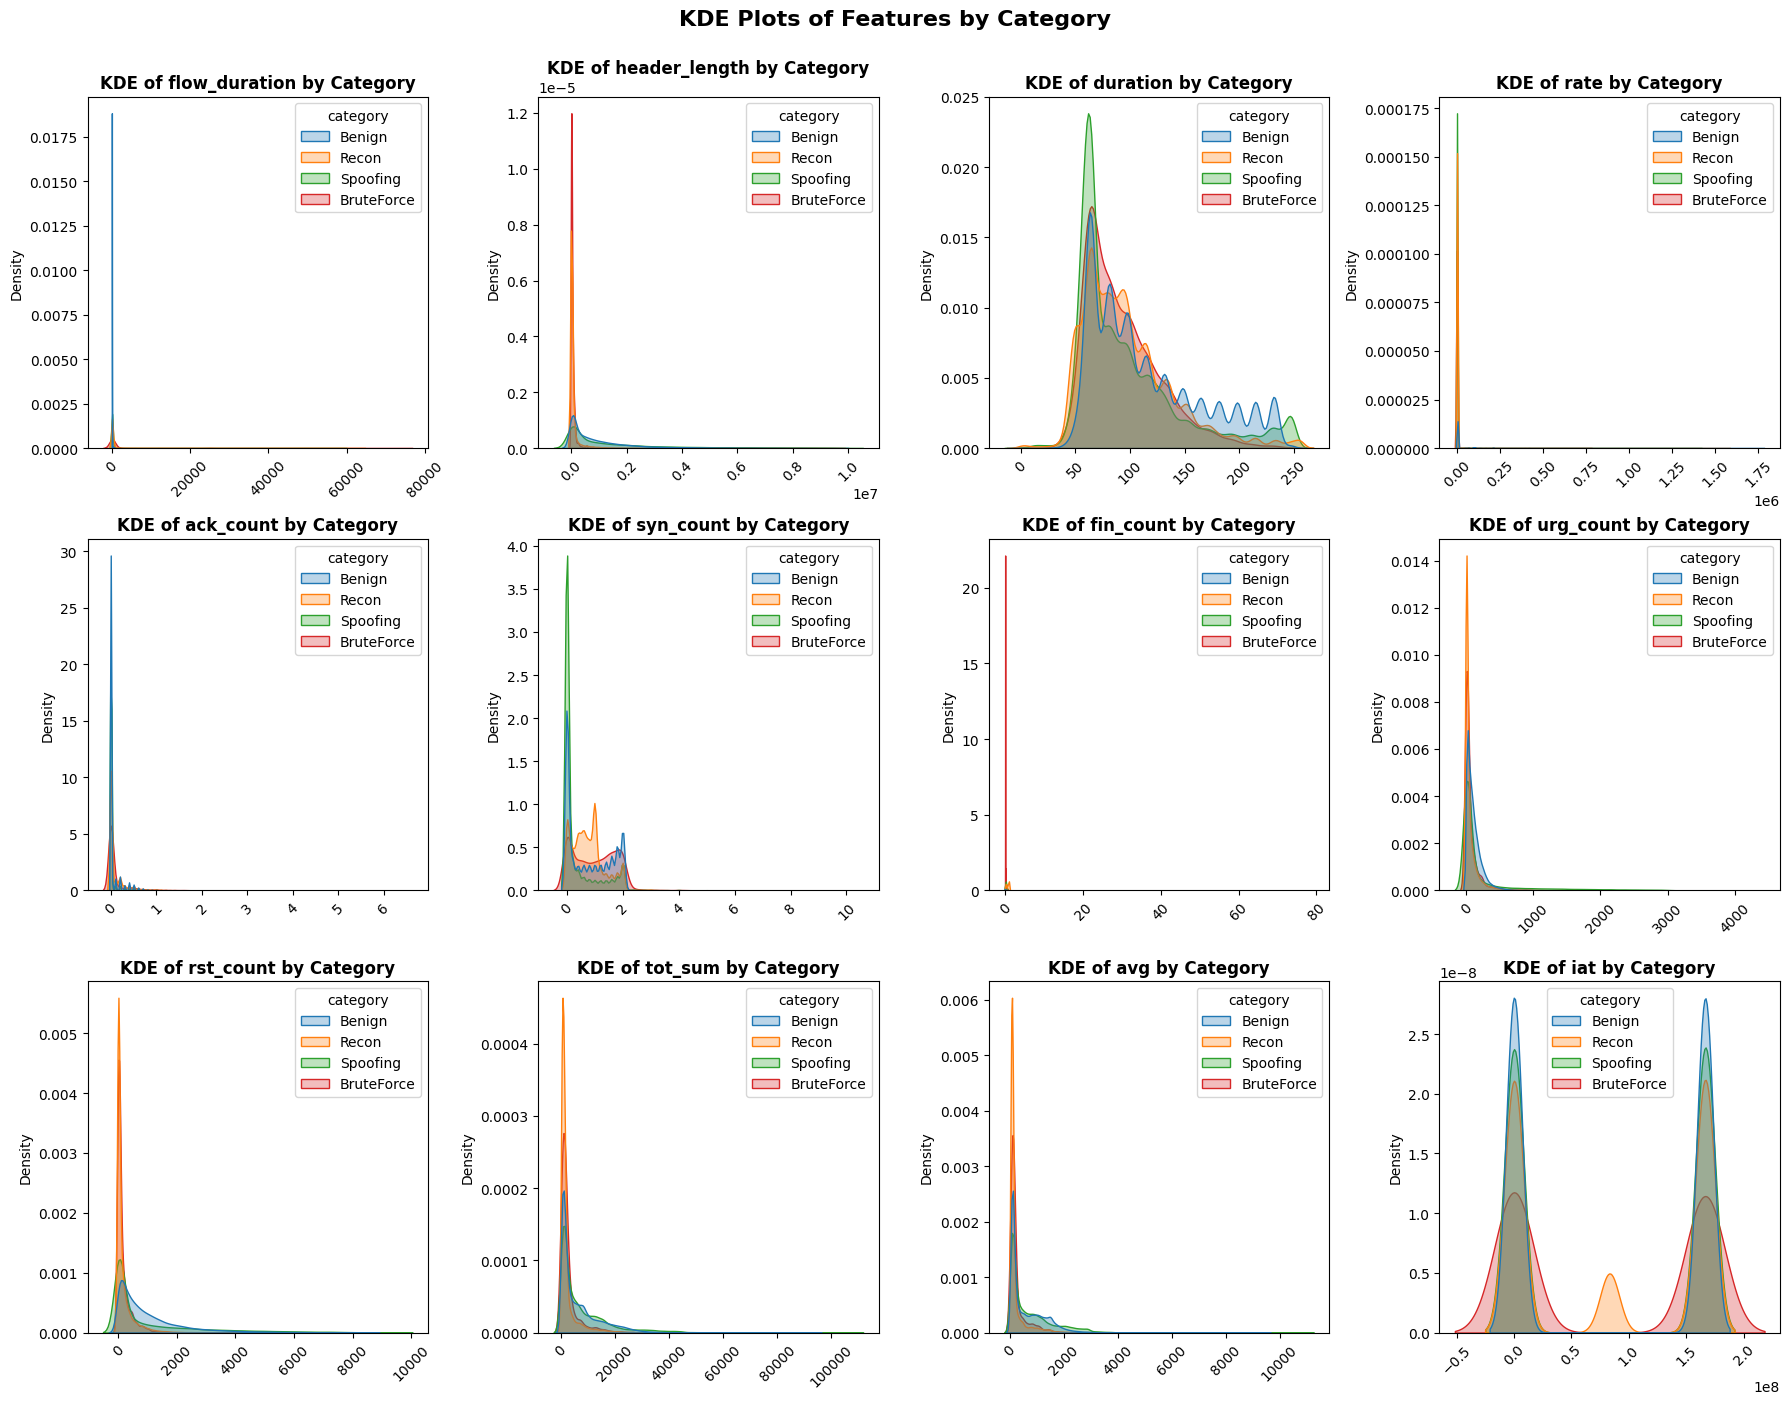

In [83]:
# KDE plot for all selected features
fig, axes = plt.subplots(3, 4, figsize=(18, 14))
axes = axes.flatten()
for idx, feature in enumerate(key_features[:12]):  
    sns.kdeplot(data=analysis_df, x=feature, hue='category', ax=axes[idx], fill=True, common_norm=False, alpha=0.3)
    axes[idx].set_title(f'KDE of {feature} by Category', fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].tick_params(axis='x', rotation=45)
plt.suptitle('KDE Plots of Features by Category', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

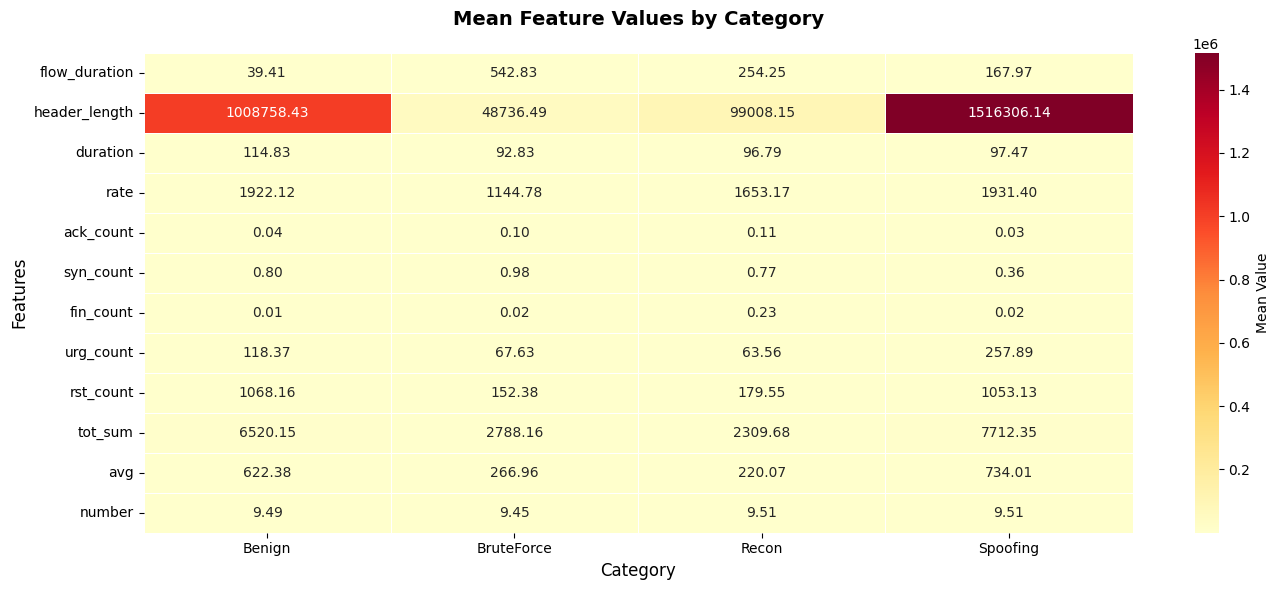

In [89]:
# Category-wise feature statistics heatmap
# Calculate mean values for each feature per category
key_features = [
    'flow_duration',
    'header_length',
    'duration',
    'rate',
    'ack_count',
    'syn_count',
    'fin_count',
    'urg_count',
    'rst_count',
    'tot_sum',
    'avg',
    'number'
]
category_stats = analysis_df.groupby('category')[key_features].mean()

plt.figure(figsize=(14, 6))
sns.heatmap(category_stats.T, annot=True, fmt='.2f', cmap='YlOrRd', 
            linewidths=0.5, cbar_kws={'label': 'Mean Value'})
plt.title('Mean Feature Values by Category', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

**Observations:**<br><br>
General:
- Benign traffic has a close distribution of features with Spoofing and Recon attacks <br>Making for a lot of false negatives.
- Spoofing has more outliers with features related to counts.

Specific:
- brute force has a lot of flow_duration outliers with small header_length.
- benign traffic has outliers for header_length with recon and spoofing.
- most of syn_counts are for spoofing, with bruteforce having the highest per flow.
- most of urg_count are for benign, with spoofing having the highest per flow.

# Conclusion

## Summary of Key Findings


### 1. Class Imbalance Issues
**Critical Challenge Identified:**
- Severe class imbalance both at category and label levels
- Benign class is heavily overrepresented
- BruteForce is significantly underrepresented

**Recommended Mitigation Strategies:**
- Apply **undersampling** for Benign category to balance with Spoofing
- Use **SMOTE** (Synthetic Minority Over-sampling Technique) for Recon and BruteForce
- Consider stratified sampling during train/test split
- Implement class weights in model training

### 2. Feature Correlation Discoveries

#### Feature Redundancy (Multicollinearity):
**Perfect Correlations (r = 1.0) - Drop One from Each Pair:**
1. `rate` ≡ `srate` (identical values across all records)
2. `llc` ≡ `ipv` (perfectly correlated)
3. `number` ≡ `weight` (deterministic relationship)
4. `radius` ≡ `std` (mathematically derived from same source)

**Zero Variance Features - Safe to Drop:**
- `dhcp` = 0 (no DHCP traffic in dataset)
- `drate` = 0 (no inbound rate variation)

**High Multicollinearity Features (|r| > 0.9):**
- `radius`, `weight`, `std`, `iat`, `max`, `number` are highly correlated with multiple features
- We will Drop these features to reduce dimensionality and prevent model overfitting

### 3. Attack Pattern Insights

#### TCP Flag Analysis:
- **SYN and RST flags** predominantly appear in **Recon attacks**
- Attackers use these flags during connection establishment attempts (port scanning, network mapping)
- Pattern is consistent with reconnaissance attack methodology

#### Flow Duration Patterns:
- **All attack categories** show **outliers with long durations**
- Benign traffic has more consistent, shorter flow durations
- Long-duration flows are strong indicators of malicious activity

#### Header Length Distribution:
- BruteForce attacks: **high flow_duration outliers** with **small header_length**
- Benign traffic: **header_length outliers** overlap with Recon and Spoofing
- This overlap creates potential for **false negatives**

### 4. Category-Specific Feature Distributions

#### General Patterns:
- **Benign traffic has close distribution overlap with Spoofing and Recon attacks**
  - Major challenge: High risk of false negatives for these attack types
  - Model must learn subtle differences, not just magnitude differences
- **Spoofing** exhibits more outliers in count-related features
  - Suggests spoofing attacks generate unusual packet count patterns

#### Discriminative Feature Insights:

**syn_count:**
- Most occurrences in **Spoofing** attacks
- **BruteForce** has highest syn_count **per flow** (intensity metric)
- Strong discriminator for these two attack types

**urg_count:**
- Most occurrences in **Benign** traffic
- **Spoofing** has highest urg_count **per flow**
- Can help distinguish Spoofing from Benign when combined with other features

**flow_duration:**
- BruteForce: Many outliers (long-running attacks)
- Can be used to separate BruteForce from other categories

**header_length:**
- BruteForce: Consistently small values even with long durations
- Benign: Outliers overlap with Recon and Spoofing (classification challenge)